In [1]:
import ast, json, math
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, precision_recall_fscore_support

### Helper constants and func

In [ ]:
DATA_DIR = Path("../data")
SRC_CSV = DATA_DIR / "combined_2017_2023_themes_with_KG.csv"
SYNTH_CSV = DATA_DIR / "synthetic_golden_set.csv"
GOLD_CSV = DATA_DIR / "synthetic_gold_themes.csv"
SPLIT_CSV = DATA_DIR / "synthetic_gold_split.csv"
FEAT_CACHE = DATA_DIR / "theme_bge_m3.npz"

RESULTS_DIR = Path("../output/exp2_chapter5")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 72
HUB_MAX_THEMES = 200  # drop entities appearing in more themes
BM25_K1 = 1.5  # BM25 saturation
PROP_BETA = 0.5  # 1 hop propagation smear weight

ALPHA = 0.5  # phrase <--> entity blend (1 = phrase only, 0 = entity only)
USE_PROPAGATION = True
ENCODE_MISSING = True  # encode cache missing themes

# type prior: concrete entities are more useful than abstract ones
CONCRETE_TYPES = {
    "COMP",
    "GPE",
    "PERSON",
    "EVENT",
    "PRODUCT",
    "ORG",
    "ORG/GOV",
    "ORG/REG",
    "CRYPTO",
}
ABSTRACT_TYPES = {
    "CONCEPT",
    "SECTOR",
    "ECON_INDICATOR",
    "MACRO_TREND",
    "TECHNOLOGY",
    "TECHNOLOGY_CONCEPT",
    "POLICY",
    "POLICY_OR_REGULATION",
    "FIN_INSTRUMENT",
    "REG",
}


def type_prior(kind):

    if kind in CONCRETE_TYPES:
        return 1.0

    if kind in ABSTRACT_TYPES:
        return 0.5

    return 0.7  # unknown


# BELONGS_TO is the only taxonomic relation (membership/ownership)
TAXONOMIC_RELATIONS = {"BELONGS_TO"}
EXCLUDED_RELATIONS = {"ACTS_ON", "HAS_ACTOR", "HAS_TARGET", "HAS_CONTEXT", "AFFECTS"}

np.random.seed(SEED)
print("config loaded")

config loaded


In [3]:
articles = pd.read_csv(SRC_CSV)
articles = articles[
    articles["themes"].notna() & articles["knowledge_graph"].notna()
].reset_index(drop=True)

In [4]:
def parse_list(value):

    if isinstance(value, list):
        return value

    try:
        return json.loads(value)

    except Exception:
        try:
            return ast.literal_eval(value)
        except Exception:
            return []


articles = pd.read_csv(SRC_CSV)
articles = articles[
    articles["themes"].notna() & articles["knowledge_graph"].notna()
].reset_index(drop=True)

articles = articles[["knowledge_graph", "themes", "date_publish"]].copy()
articles["kg"] = articles["knowledge_graph"].apply(parse_list)
articles["themes"] = articles["themes"].apply(parse_list)
articles["date"] = pd.to_datetime(articles["date_publish"], errors="coerce")
articles = articles.drop(columns=["knowledge_graph", "date_publish"])


# paraphrased gold articles join the pool so their themes get entity vectors /
# embeddings and the golden-set eval below has clusters to score
synthetic = pd.read_csv(SYNTH_CSV)
synthetic_articles = pd.DataFrame(
    {
        "themes": synthetic["themes"].apply(parse_list),
        "kg": synthetic["knowledge_graph"].apply(parse_list),
        "date": pd.NaT,
    }
)

n_real = len(articles)
articles = pd.concat([articles, synthetic_articles], ignore_index=True)
print(f"{n_real} real + {len(synthetic_articles)} synthetic articles = {len(articles)}")

5433 real + 1068 synthetic articles = 6501


### Article level co occurrence

In [ ]:
n_articles = len(articles)
theme_entity_article_counts = defaultdict(int)  # (theme, entity) --> articles
articles_per_entity = Counter()
entity_type = {}  # entity -> ontology type (first seen)
dimension_votes = defaultdict(Counter)  # theme -> Counter(dimension)
theme_dates = defaultdict(list)

for kg_list, published in zip(articles["kg"], articles["date"]):

    entities_by_theme = defaultdict(set)
    entities_in_article = set()
    for record in kg_list:
        triplet = record.get("triplet", [])
        theme = record.get("theme", "")
        dimension = record.get("dimension", "")

        if len(triplet) != 5 or not theme:
            continue

        head, head_type, relation, tail, tail_type = triplet

        for entity, kind in ((head, head_type), (tail, tail_type)):
            if entity == theme:
                continue

            entities_by_theme[theme].add(entity)
            entities_in_article.add(entity)
            entity_type.setdefault(entity, kind)

        if dimension:
            dimension_votes[theme][dimension] += 1

    for theme, entities in entities_by_theme.items():

        for entity in entities:
            theme_entity_article_counts[(theme, entity)] += 1

        if pd.notna(published):
            theme_dates[theme].append(published)

    for entity in entities_in_article:
        articles_per_entity[entity] += 1

# drop hub entities (appear in too many articles)
themes_per_entity = Counter()
for theme, entity in theme_entity_article_counts:
    themes_per_entity[entity] += 1

hub_entities = {e for e, n in themes_per_entity.items() if n > HUB_MAX_THEMES}

theme_to_entities = defaultdict(set)
for theme, entity in theme_entity_article_counts:
    if entity not in hub_entities:
        theme_to_entities[theme].add(entity)

theme_list = sorted(t for t, entities in theme_to_entities.items() if entities)
entity_list = sorted({e for entities in theme_to_entities.values() for e in entities})
theme_index = {t: i for i, t in enumerate(theme_list)}
entity_index = {e: i for i, e in enumerate(entity_list)}
theme_dimension = {
    t: dimension_votes[t].most_common(1)[0][0] for t in theme_list if dimension_votes[t]
}
DIMENSIONS = sorted(set(theme_dimension.values()))

print(
    f"Themes: {len(theme_list):,} | entities (non-hub): {len(entity_list):,} | hubs: {len(hub_entities):,}"
)
print(f"Dimensions: {DIMENSIONS}")

max_count = max(theme_entity_article_counts.values())
print(
    f"max Entity_freq(entity, theme) = {max_count}  (should be > 1) | max df_articles = {max(articles_per_entity.values())}"
)

themes: 15,296 | entities (non-hub): 34,672 | hubs: 8
dimensions: ['economic_monetary_event', 'geopolitical_factor', 'macro_trend', 'policy_or_regulation', 'sector_or_industry', 'technology_concept']
max EF(e,theme) = 201  (should be > 1) | max df_articles = 746


### Precalculate sparse ingredients for weight(entity, theme)

Builds the sparse theme x entity co occurrence counts plus the per entity IDF and type prior scalers


In [ ]:
pair_rows, pair_cols, pair_counts = [], [], []
for (theme, entity), count in theme_entity_article_counts.items():
    i = theme_index.get(theme)
    j = entity_index.get(entity)

    if i is None or j is None:
        continue

    pair_rows.append(i)
    pair_cols.append(j)
    pair_counts.append(count)

pair_rows = np.array(pair_rows)
pair_cols = np.array(pair_cols)
pair_counts = np.array(pair_counts, dtype=np.float64)

# BM25 saturation
saturated_counts = (pair_counts * (BM25_K1 + 1.0)) / (pair_counts + BM25_K1)

entity_idf = np.array(
    [math.log(n_articles / articles_per_entity[e]) for e in entity_list]
)
entity_prior = np.array([type_prior(entity_type.get(e, "UNK")) for e in entity_list])

n_themes, n_entities = len(theme_list), len(entity_list)
print(
    f"nnz weight entries: {len(pair_counts):,} over {n_themes}x{n_entities} theme entity matrix"
)

nnz weight entries: 75,241 over 15296x34672 theme-entity matrix


### 1 hop KG propagation graph

Entity <--> entity adjacency built **only** from taxonomic relations (`Is_Member_Of, Operate_In, Has,
Invests_In`)

Applied as `W ← W + β·(W @ A)`


In [ ]:
def normalize_relation(relation):
    return str(relation).strip().replace(" ", "_")


edge_rows, edge_cols = [], []
for kg_list in articles["kg"]:
    for record in kg_list:
        triplet = record.get("triplet", [])

        if len(triplet) != 5:
            continue

        head, _, relation, tail, _ = triplet
        relation = normalize_relation(relation)

        if relation in EXCLUDED_RELATIONS or relation not in TAXONOMIC_RELATIONS:
            continue

        i, j = entity_index.get(head), entity_index.get(tail)

        if i is None or j is None or i == j:
            continue

        edge_rows += [i, j]  # undirected smear
        edge_cols += [j, i]


taxonomy_edges = (
    sp.csr_matrix(
        (np.ones(len(edge_rows)), (edge_rows, edge_cols)),
        shape=(n_entities, n_entities),
    )
    if edge_rows
    else sp.csr_matrix((n_entities, n_entities))
)

print(f"Taxonomic entity <--> entity edges (undirected): {taxonomy_edges.nnz:,}")

taxonomic entity-entity edges (undirected): 16,734


### Theme entity vectors + bge-m3 phrase embeddings

In [ ]:
def build_entity_matrix(use_propagation=False):

    data = saturated_counts * entity_idf[pair_cols] * entity_prior[pair_cols]
    weights = sp.csr_matrix(
        (data, (pair_rows, pair_cols)), shape=(n_themes, n_entities)
    )

    if use_propagation and taxonomy_edges.nnz:
        weights = weights + PROP_BETA * (weights @ taxonomy_edges)

    return normalize(weights, norm="l2", axis=1)


# phrase embeddings (bge-m3), cache shared with cluster_themes.ipynb
cached = {}
if FEAT_CACHE.exists():
    archive = np.load(FEAT_CACHE, allow_pickle=True)
    cached = dict(zip(archive["themes"].tolist(), archive["vecs"]))

    del archive

missing = [t for t in theme_list if t not in cached]
print(
    f"themes in bge cache: {len(theme_list) - len(missing)} / {len(theme_list)} "
    f"| missing: {len(missing)}"
)

if missing and ENCODE_MISSING:

    from sentence_transformers import SentenceTransformer

    encoder = SentenceTransformer("BAAI/bge-m3")
    new_vecs = encoder.encode(
        missing, batch_size=64, show_progress_bar=True, normalize_embeddings=True
    )
    cached.update(zip(missing, new_vecs.astype(np.float32)))
    np.savez_compressed(
        FEAT_CACHE,
        themes=np.array(list(cached.keys()), dtype=object),
        vecs=np.stack(list(cached.values())).astype(np.float32),
    )
    print(f"encoded {len(missing)} new themes -> {FEAT_CACHE}")

elif missing:
    print(f"{len(missing)} themes kept as zero vectors (become singletons)")


embedding_dim = len(next(iter(cached.values()))) if cached else 1024
phrase_vecs = np.stack(
    [cached.get(t, np.zeros(embedding_dim, np.float32)) for t in theme_list]
).astype(np.float32)
phrase_vecs = normalize(phrase_vecs, norm="l2", axis=1)

phrase_vecs = np.nan_to_num(phrase_vecs, nan=0.0, posinf=0.0, neginf=0.0)
print("phrase matrix:", phrase_vecs.shape)

themes in bge cache: 15296 / 15296 | missing: 0
phrase matrix: (15296, 1024)


### Similarity + HAC

In [ ]:
def average_linkage_clusterer(tau):

    try:

        return AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=tau,
            metric="precomputed",
            linkage="average",
        )
    except TypeError:

        return AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=tau,
            affinity="precomputed",
            linkage="average",
        )


def cluster_themes(alpha, tau, entity_vecs):

    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        sim = (phrase_vecs @ phrase_vecs.T) * np.float32(alpha)

        if alpha < 1.0 and entity_vecs is not None:
            entity_sim = (entity_vecs @ entity_vecs.T).toarray()
            sim += (entity_sim * (1.0 - alpha)).astype(np.float32)

            del entity_sim

    dist = np.subtract(np.float32(1.0), sim, out=sim)
    np.clip(dist, 0.0, None, out=dist)

    dist = np.nan_to_num(dist, nan=1.0, copy=False)
    np.fill_diagonal(dist, 0.0)

    cluster_ids = average_linkage_clusterer(tau).fit_predict(dist)
    del dist

    return {t: f"c{cluster_ids[i]}" for i, t in enumerate(theme_list)}


print("cluster_themes ready")

cluster_themes ready


### Top weighted entities per theme

In [ ]:
raw_weights = sp.csr_matrix(
    (
        saturated_counts * entity_idf[pair_cols] * entity_prior[pair_cols],
        (pair_rows, pair_cols),
    ),
    shape=(n_themes, n_entities),
)

for theme in theme_list[:5]:

    row = raw_weights.getrow(theme_index[theme]).toarray().ravel()
    top = np.argsort(-row)[:6]
    described = [
        f"{entity_list[j]}({entity_type.get(entity_list[j], '?')}:{row[j]:.2f})"
        for j in top
        if row[j] > 0
    ]

    print(f"[{theme_dimension.get(theme, '?')}] {theme!r}")
    print("   ", " | ".join(described), "\n")

[policy_or_regulation] '1031 tax-deferred exchange'
    IPX1031(ORG:8.78) | real estate sector(SECTOR:2.89) 

[macro_trend] '1980s nostalgia trend'
    Takeshi's Castle(PRODUCT:8.78) | Frogger(PRODUCT:8.78) | Peacock(PRODUCT:7.17) 

[technology_concept] '3D bioprinting collaboration'
    CollPlant Biotechnologies(COMP:8.78) | soft tissue matrix(PRODUCT:8.78) | 3D Systems(COMP:7.39) | breast reconstruction(SECTOR:4.39) 

[technology_concept] '3D perception technology uptake'
    LX Semicon(COMP:10.56) | Amazon Depth Service(PRODUCT:8.78) | depth sensing modules(PRODUCT:8.78) | computer vision platforms(PRODUCT:8.78) | Meta Reality Labs Depth(PRODUCT:8.78) | machine vision solutions(PRODUCT:7.68) 

[technology_concept] '3D printed wearable technology'
    orthopedic implants(PRODUCT:8.78) | Arcam AB(COMP:8.78) | hybrid 3D printing technology(PRODUCT:8.78) | hospital(ORG:8.78) | EnvisionTEC(COMP:8.78) | Wyss Institute(ORG:8.78) 



### Gold evaluation helper

In [ ]:
def load_gold():

    gold = pd.read_csv(GOLD_CSV)
    gold = gold[gold["keep"] == 1]

    cluster_sizes = gold["gold_cluster_id"].value_counts()
    gold = gold[gold["gold_cluster_id"].isin(cluster_sizes[cluster_sizes >= 2].index)]
    split = pd.read_csv(SPLIT_CSV)[["theme", "split"]]

    return gold.merge(split, on="theme", how="left").reset_index(drop=True)


def pairwise_scores(frame, theme_to_cluster):

    frame = frame[frame["theme"].isin(set(theme_to_cluster))]

    if len(frame) < 2:
        return None

    gold_ids = pd.factorize(frame["gold_cluster_id"])[0]
    predicted_ids = pd.factorize(
        np.array([theme_to_cluster[t] for t in frame["theme"]])
    )[0]

    pair_index = np.triu_indices(len(frame), k=1)
    same_gold = (gold_ids[:, None] == gold_ids[None, :])[pair_index]
    same_predicted = (predicted_ids[:, None] == predicted_ids[None, :])[pair_index]

    precision, recall, f1, _ = precision_recall_fscore_support(
        same_gold, same_predicted, average="binary", zero_division=0
    )

    return {
        "themes": len(frame),
        "clusters": frame["gold_cluster_id"].nunique(),
        "pairs": same_gold.size,
        "pos_pairs": int(same_gold.sum()),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "ARI": adjusted_rand_score(gold_ids, predicted_ids),
    }


gold_all = load_gold()
gold_val = gold_all[gold_all["split"] == "val"]


def score_against_gold(theme_to_cluster):

    scored = pairwise_scores(gold_val, theme_to_cluster)
    if scored is None:
        return {}

    return {
        "val_P": scored["precision"],
        "val_R": scored["recall"],
        "val_F1": scored["f1"],
        "val_ARI": scored["ARI"],
        "val_n": scored["themes"],
    }


assert gold_all.groupby("gold_cluster_id")["split"].nunique().max() <= 1

coverage = gold_all.assign(covered=gold_all["theme"].isin(set(theme_index)))
print(
    f"gold themes: {len(gold_all):,}  ({coverage['covered'].sum():,} present in theme_index)"
)
print(
    coverage.groupby("split", dropna=False)
    .agg(
        themes=("theme", "size"),
        covered=("covered", "sum"),
        clusters=("gold_cluster_id", "nunique"),
    )
    .to_string()
)

gold themes: 3,134  (3,130 present in theme_index)
       themes  covered  clusters
split                           
test      628      628       201
train    1854     1854       600
val       648      648       200
NaN         4        0         2


### Ablation sweep + evaluation

Sweeps different blends across τ threshold with and without propagation.

In [ ]:
TAU_GRID = [0.5, 0.6, 0.7, 0.8, 0.9, 1.5, 2, 2.5]
ALPHA_GRID = [0.3, 0.5, 0.7]

_entity_vecs_cache = {}


def entity_vecs_for(use_propagation):
    if use_propagation not in _entity_vecs_cache:
        _entity_vecs_cache[use_propagation] = build_entity_matrix(use_propagation)

    return _entity_vecs_cache[use_propagation]


def evaluate(name, alpha, use_propagation, tau):
    entity_vecs = None if alpha >= 1.0 else entity_vecs_for(use_propagation)
    theme_to_cluster = cluster_themes(alpha, tau, entity_vecs)
    run = {
        "method": name,
        "alpha": alpha,
        "prop": use_propagation,
        "tau": tau,
        "n_clusters": len(set(theme_to_cluster.values())),
    }
    run.update(score_against_gold(theme_to_cluster))

    return run


runs = []
for tau in TAU_GRID:
    runs.append(evaluate("phrase-only", 1.0, False, tau))  # baseline
    runs.append(evaluate("entity-only", 0.0, False, tau))

    for alpha in ALPHA_GRID:
        runs.append(evaluate(f"blend(a={alpha})", alpha, False, tau))
        runs.append(evaluate(f"blend(prop,a={alpha})", alpha, True, tau))

ablation = pd.DataFrame(runs)
SHOW_COLS = [
    "method",
    "tau",
    "val_P",
    "val_R",
    "val_F1",
    "val_ARI",
    "n_clusters",
    "val_n",
]
ablation_ranked = ablation.sort_values("val_F1", ascending=False).round(3)
print("TOP configs by val_F1 (selection split — `test` is untouched here):")
print(ablation_ranked[SHOW_COLS].head(15).to_string(index=False))

TOP configs by val_F1 (selection split — `test` is untouched here):
           method  tau  val_P  val_R  val_F1  val_ARI  n_clusters  val_n
     blend(a=0.7)  0.5  0.855  0.774   0.813    0.812        5156    648
     blend(a=0.5)  0.6  0.798  0.776   0.787    0.786        6486    648
     blend(a=0.5)  0.5  0.940  0.662   0.777    0.776       10013    648
     blend(a=0.5)  0.7  0.638  0.876   0.738    0.737        2555    648
blend(prop,a=0.7)  0.5  0.708  0.758   0.732    0.731        4574    648
     blend(a=0.3)  0.6  0.793  0.658   0.719    0.718        8434    648
     blend(a=0.3)  0.5  0.927  0.578   0.712    0.711       10615    648
     blend(a=0.3)  0.7  0.723  0.694   0.708    0.707        6103    648
     blend(a=0.3)  0.8  0.652  0.765   0.704    0.702        3228    648
      entity-only  0.6  0.846  0.577   0.686    0.685        9303    648
      entity-only  0.7  0.741  0.625   0.678    0.677        7590    648
      entity-only  0.8  0.699  0.641   0.668    0.667   

In [ ]:
best_phrase = (
    ablation[ablation["method"] == "phrase only"]
    .sort_values("val_F1", ascending=False)
    .iloc[0]
)
best = ablation.sort_values("val_F1", ascending=False).iloc[0]
print(
    f"phrase only, best: val_F1={best_phrase.val_F1:.3f}  val_ARI={best_phrase.val_ARI:.3f}  (tau={best_phrase.tau})"
)
print(
    f"Overall, best: val_F1={best.val_F1:.3f}  val_ARI={best.val_ARI:.3f}"
    f"[{best.method}, tau={best.tau}]"
)

lift = best.val_F1 - best_phrase.val_F1
print(f"Entity weighting lift over phrase only: {lift:+.3f} val_F1")

# persist the winning canonicalization — refit over ALL themes (clustering is unsupervised
# only the *scoring* above was restricted to `val`)
winning_entity_vecs = None if best.alpha >= 1.0 else entity_vecs_for(best.prop)
final_clusters = cluster_themes(best.alpha, best.tau, winning_entity_vecs)
assignments = pd.DataFrame(
    {
        "theme": list(final_clusters.keys()),
        "canon_cluster": list(final_clusters.values()),
    }
)

assignments["dimension"] = assignments["theme"].map(theme_dimension)
assignments_path = RESULTS_DIR / "canon_entity_tfidf.csv"
assignments.to_csv(assignments_path, index=False)
print(f"output {len(assignments)} theme to cluster assignments to {assignments_path}")

ablation_path = RESULTS_DIR / "canon_entity_tfidf_ablation.csv"
ablation.to_csv(ablation_path, index=False)
print(f"output {len(ablation)} ablation rows to {ablation_path}")

phrase-only  best: val_F1=0.320  val_ARI=0.316  (tau=0.5)
overall      best: val_F1=0.813  val_ARI=0.812  [blend(a=0.7), tau=0.5]

entity-weighting lift over phrase-only: +0.492 val_F1

wrote 15296 theme->cluster assignments to ../output/exp2_chapter5/canon_entity_tfidf.csv
wrote 64 ablation rows to ../output/exp2_chapter5/canon_entity_tfidf_ablation.csv


In [ ]:
theme_to_cluster = final_clusters
SOURCE_CSV = SRC_CSV

REPORT_DIR = RESULTS_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

JOIN = " | "
REPORT_COLS = [
    "article_id",
    "title",
    "url",
    "date_publish",
    "themes",
    "knowledge_graph",
]


def joined(values):
    return JOIN.join(str(v).replace("|", "/") for v in values)


article_rows, triple_rows = [], []
for chunk in pd.read_csv(SOURCE_CSV, usecols=REPORT_COLS, chunksize=20_000):
    chunk = chunk[chunk["themes"].notna() & chunk["knowledge_graph"].notna()]
    for row in chunk.itertuples(index=False):
        for entry in json.loads(row.themes):
            article_rows.append(
                (
                    entry["theme"],
                    entry.get("dimension"),
                    row.article_id,
                    row.title,
                    row.date_publish,
                    row.url,
                )
            )
        for record in json.loads(row.knowledge_graph):
            triplet = record.get("triplet", [])
            if len(triplet) != 5 or not record.get("theme"):
                continue
            head, head_type, relation, tail, tail_type = triplet
            triple_rows.append(
                (
                    record["theme"],
                    row.article_id,
                    head,
                    head_type,
                    relation,
                    tail,
                    tail_type,
                )
            )

theme_articles = pd.DataFrame(
    article_rows,
    columns=["theme", "dimension", "article_id", "title", "date_publish", "url"],
).drop_duplicates()
theme_triples = pd.DataFrame(
    triple_rows,
    columns=[
        "theme",
        "article_id",
        "head",
        "head_type",
        "relation",
        "tail",
        "tail_type",
    ],
)
print(
    f"corpus index: {len(theme_articles):,} theme-article pairs over "
    f"{theme_articles['theme'].nunique():,} themes | {len(theme_triples):,} triples"
)

_archive = np.load(DATA_DIR / "theme_bge_m3.npz", allow_pickle=True)
phrase_vectors = dict(zip(_archive["themes"].tolist(), _archive["vecs"]))

report_members = defaultdict(list)
for theme, cluster in theme_to_cluster.items():
    report_members[cluster].append(theme)

cluster_label, cluster_cohesion = {}, {}
for cluster, members in report_members.items():
    known = [m for m in members if m in phrase_vectors]
    if not known:
        cluster_label[cluster] = sorted(members)[0]
        cluster_cohesion[cluster] = float("nan")
        continue
    vectors = np.stack([phrase_vectors[m] for m in known]).astype(np.float32)
    vectors /= np.maximum(np.linalg.norm(vectors, axis=1, keepdims=True), 1e-12)
    centroid = vectors.mean(axis=0)
    centroid /= max(float(np.linalg.norm(centroid)), 1e-12)
    cluster_label[cluster] = known[int(np.argmax(vectors @ centroid))]
    if len(known) > 1:
        sims = vectors @ vectors.T
        cluster_cohesion[cluster] = float(sims[np.triu_indices(len(known), 1)].mean())
    else:
        cluster_cohesion[cluster] = float("nan")

assignments_long = pd.DataFrame(
    {
        "canon_cluster": list(theme_to_cluster.values()),
        "theme": list(theme_to_cluster),
    }
)
assignments_long["cluster_label"] = assignments_long["canon_cluster"].map(cluster_label)


article_map = assignments_long.merge(theme_articles, on="theme", how="left")
article_map["is_synthetic"] = article_map["article_id"].isna()
article_map = article_map[
    [
        "canon_cluster",
        "cluster_label",
        "theme",
        "dimension",
        "article_id",
        "title",
        "date_publish",
        "url",
        "is_synthetic",
    ]
].sort_values(["canon_cluster", "theme", "article_id"], na_position="last")
article_map.to_csv(REPORT_DIR / "cluster_theme_article_map.csv", index=False)

triple_map = assignments_long.merge(theme_triples, on="theme", how="inner")
triple_map = triple_map[
    [
        "canon_cluster",
        "cluster_label",
        "theme",
        "article_id",
        "head",
        "head_type",
        "relation",
        "tail",
        "tail_type",
    ]
].sort_values(["canon_cluster", "theme", "article_id"])
triple_map.to_csv(REPORT_DIR / "cluster_kg_triples.csv", index=False)

themes_with_articles = set(theme_articles["theme"])
real_rows = article_map[~article_map["is_synthetic"]]
articles_by_cluster = dict(tuple(real_rows.groupby("canon_cluster")))
triples_by_cluster = dict(tuple(triple_map.groupby("canon_cluster")))

summary_rows = []
for cluster, members in report_members.items():
    members = sorted(members)
    cluster_articles = articles_by_cluster.get(cluster)
    cluster_triples = triples_by_cluster.get(cluster)

    if cluster_articles is None:
        article_ids, titles, dimensions = [], [], Counter()
    else:
        article_ids = list(dict.fromkeys(cluster_articles["article_id"]))
        dimensions = Counter(cluster_articles["dimension"].dropna())

        ranked = cluster_articles.assign(
            _off_label=cluster_articles["theme"].ne(cluster_label[cluster]),
            _date=pd.to_datetime(cluster_articles["date_publish"], errors="coerce"),
        ).sort_values(["_off_label", "_date"], ascending=[True, False])
        titles = list(dict.fromkeys(ranked["title"].dropna()))

    entities = (
        Counter()
        if cluster_triples is None
        else Counter(zip(cluster_triples["tail"], cluster_triples["tail_type"]))
    )

    summary_rows.append(
        {
            "canon_cluster": cluster,
            "label": cluster_label[cluster],
            "n_themes": len(members),
            "n_articles": len(article_ids),
            "n_triples": 0 if cluster_triples is None else len(cluster_triples),
            "cohesion": cluster_cohesion[cluster],
            "dimensions": joined(f"{d}:{n}" for d, n in dimensions.most_common()),
            "member_themes": joined(members),
            "top_entities": joined(
                f"{entity} ({etype}) ×{n}"
                for (entity, etype), n in entities.most_common(10)
            ),
            "article_ids": joined(article_ids),
            "sample_titles": joined(titles[:5]),
            "n_synthetic_themes": sum(
                1 for m in members if m not in themes_with_articles
            ),
        }
    )

summary = pd.DataFrame(summary_rows).sort_values(
    ["n_themes", "canon_cluster"], ascending=[False, True]
)
summary.to_csv(REPORT_DIR / "cluster_summary.csv", index=False)

covered = sum(1 for t in theme_to_cluster if t in themes_with_articles)
print(
    f"report -> {REPORT_DIR}\n"
    f"cluster_summary.csv {len(summary):,} clusters\n"
    f"cluster_theme_article_map.csv {len(article_map):,} rows\n"
    f"cluster_kg_triples.csv {len(triple_map):,} rows\n"
    f"{covered:,} / {len(theme_to_cluster):,} themes trace to a real article "
    f"({len(theme_to_cluster) - covered:,} synthetic)"
)

corpus index: 17,201 theme-article pairs over 13,268 themes | 87,969 triples


/var/folders/g5/tqsgxfp922q6lw1z0fkx4k_00000gn/T/ipykernel_13567/3974105318.py:104: RuntimeWarning: divide by zero encountered in matmul
  cluster_label[cluster] = known[int(np.argmax(vectors @ centroid))]
/var/folders/g5/tqsgxfp922q6lw1z0fkx4k_00000gn/T/ipykernel_13567/3974105318.py:104: RuntimeWarning: overflow encountered in matmul
  cluster_label[cluster] = known[int(np.argmax(vectors @ centroid))]
/var/folders/g5/tqsgxfp922q6lw1z0fkx4k_00000gn/T/ipykernel_13567/3974105318.py:104: RuntimeWarning: invalid value encountered in matmul
  cluster_label[cluster] = known[int(np.argmax(vectors @ centroid))]
/var/folders/g5/tqsgxfp922q6lw1z0fkx4k_00000gn/T/ipykernel_13567/3974105318.py:106: RuntimeWarning: divide by zero encountered in matmul
  sims = vectors @ vectors.T
/var/folders/g5/tqsgxfp922q6lw1z0fkx4k_00000gn/T/ipykernel_13567/3974105318.py:106: RuntimeWarning: overflow encountered in matmul
  sims = vectors @ vectors.T
/var/folders/g5/tqsgxfp922q6lw1z0fkx4k_00000gn/T/ipykernel_1356

report -> ../output/exp2_chapter5/report
cluster_summary.csv            5,156 clusters
cluster_theme_article_map.csv  19,229 rows
cluster_kg_triples.csv         87,957 rows
13,260 / 15,296 themes trace to a real article (2,036 synthetic)


### Evaluation on the golden set

In [ ]:
gold = gold_all[gold_all["theme"].isin(set(final_clusters))].reset_index(drop=True)
print(f"gold themes covered: {len(gold)} / {len(gold_all)}")

by_split = {}
for name in ("train", "val", "test"):
    scored = pairwise_scores(gold[gold["split"] == name], final_clusters)
    if scored:
        by_split[name] = scored

by_split["whole gold set"] = pairwise_scores(gold, final_clusters)

results = pd.DataFrame(by_split).T
results.index.name = "split"
metrics_path = RESULTS_DIR / "exp2_metrics.csv"
results.to_csv(metrics_path)

print(results.to_string(float_format=lambda x: f"{x:.3f}"))
print(f"Output metrics -> {metrics_path}")

held_out = results.loc["test"]
print(
    f"TEST; pairwise P/R/F1:"
    f"{held_out['precision']:.3f} / {held_out['recall']:.3f} / {held_out['f1']:.3f}"
    f"ARI: {held_out['ARI']:.3f} (n = {int(held_out['themes'])} themes)"
)

gold themes covered: 3130 / 3134

                 themes  clusters       pairs  pos_pairs  precision  recall    f1   ARI
split                                                                                  
train          1854.000   600.000 1717731.000   2032.000      0.754   0.879 0.812 0.812
val             648.000   200.000  209628.000    854.000      0.855   0.774 0.813 0.812
test            628.000   201.000  196878.000    732.000      0.892   0.848 0.870 0.869
whole gold set 3130.000  1001.000 4896885.000   3618.000      0.589   0.848 0.695 0.695

wrote metrics -> ../output/exp2_chapter5/exp2_metrics.csv

HELD-OUT TEST — pairwise P/R/F1: 0.892 / 0.848 / 0.870   ARI: 0.869   (n = 628 themes)


In [ ]:
# variant breakdown: Original themes x variant K paraphrases

originals = gold[gold["role"] == "original"]
original_pred = np.array([final_clusters[t] for t in originals["theme"]])

breakdown = {}
for variant in ("syn1", "syn2", "syn3"):
    variants = gold[gold[f"in_{variant}"]]
    variant_pred = np.array([final_clusters[t] for t in variants["theme"]])

    is_same_gold = (
        originals["gold_cluster_id"].to_numpy()[:, None]
        == variants["gold_cluster_id"].to_numpy()[None, :]
    ).ravel()
    is_same_pred = (original_pred[:, None] == variant_pred[None, :]).ravel()

    # drop identical-phrase pairs (trivially same cluster)
    distinct = (
        originals["theme"].to_numpy()[:, None] != variants["theme"].to_numpy()[None, :]
    ).ravel()
    is_same_gold, is_same_pred = is_same_gold[distinct], is_same_pred[distinct]

    precision, recall, f1, _ = precision_recall_fscore_support(
        is_same_gold, is_same_pred, average="binary", zero_division=0
    )

    breakdown[f"parent-{variant}"] = {
        "n_pairs": is_same_gold.size,
        "n_pos": int(is_same_gold.sum()),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

print(pd.DataFrame(breakdown).T.round(3).to_string())

               n_pairs   n_pos  precision  recall     f1
parent-syn1  1078229.0  1096.0      0.669   0.972  0.792
parent-syn2  1093586.0  1132.0      0.676   0.820  0.741
parent-syn3  1090517.0  1129.0      0.675   0.819  0.740


### Vizualize KG

In [17]:
import matplotlib.pyplot as plt
import networkx as nx

# full per-theme triplets and entities (hubs included, for a complete picture)
theme_triplets = defaultdict(list)
theme_entities_full = defaultdict(set)
for kg_list in articles["kg"]:
    for record in kg_list:
        triplet, theme = record.get("triplet", []), record.get("theme", "")
        if len(triplet) != 5 or not theme:
            continue
        head, head_type, relation, tail, tail_type = triplet
        theme_triplets[theme].append((head, head_type, relation, tail, tail_type))
        theme_entities_full[theme].update([head, tail])
        theme_entities_full[theme].discard(theme)

THEME_COLORS = [
    "#e6194B",
    "#3cb44b",
    "#4363d8",
    "#f58231",
    "#911eb4",
    "#42d4f4",
    "#f032e6",
    "#9A6324",
    "#808000",
    "#000075",
]
ENTITY_COLORS = {
    "COMP": "#1f77b4",
    "ORG": "#1f77b4",
    "ORG/GOV": "#17becf",
    "ORG/REG": "#17becf",
    "GPE": "#2ca02c",
    "PERSON": "#9467bd",
    "EVENT": "#d62728",
    "PRODUCT": "#ff7f0e",
    "SECTOR": "#8c564b",
    "CONCEPT": "#7f7f7f",
    "ECON_INDICATOR": "#bcbd22",
    "MACRO_TREND": "#e377c2",
    "TECHNOLOGY": "#00a0a0",
    "FIN_INSTRUMENT": "#aec7e8",
    "POLICY": "#c49c94",
}


def draw_cluster_kg(member_themes, ax):
    graph = nx.DiGraph()
    for theme in member_themes:
        for head, head_type, relation, tail, tail_type in theme_triplets.get(theme, []):
            if head == tail:
                continue
            graph.add_edge(head, tail, kind="rel")
    entity_nodes = list(graph.nodes)
    theme_color = {}
    for i, theme in enumerate(member_themes):
        theme_color[theme] = THEME_COLORS[i % len(THEME_COLORS)]
        graph.add_node(theme)
        for entity in theme_entities_full.get(theme, set()):
            if entity in entity_nodes and entity != theme:
                graph.add_edge(theme, entity, kind="about", theme=theme)

    pos = nx.spring_layout(graph, seed=42, k=0.9)
    nx.draw_networkx_nodes(
        graph,
        pos,
        nodelist=entity_nodes,
        node_size=260,
        node_color=[
            ENTITY_COLORS.get(entity_type.get(n, ""), "#cccccc") for n in entity_nodes
        ],
        ax=ax,
        edgecolors="white",
    )
    nx.draw_networkx_nodes(
        graph,
        pos,
        nodelist=list(member_themes),
        node_size=900,
        node_shape="*",
        node_color=[theme_color[t] for t in member_themes],
        ax=ax,
        edgecolors="black",
    )
    relation_edges = [
        (u, v) for u, v, d in graph.edges(data=True) if d["kind"] == "rel"
    ]
    about_edges = [
        (u, v, d) for u, v, d in graph.edges(data=True) if d["kind"] == "about"
    ]
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=relation_edges,
        edge_color="#bbbbbb",
        width=1,
        ax=ax,
        arrows=False,
    )
    for u, v, d in about_edges:
        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=[(u, v)],
            edge_color=[theme_color[d["theme"]]],
            width=1.5,
            alpha=0.6,
            ax=ax,
            arrows=False,
        )
    labels = {n: (n if len(str(n)) <= 28 else str(n)[:26] + "…") for n in graph.nodes}
    nx.draw_networkx_labels(graph, pos, labels, font_size=7, ax=ax)
    ax.set_axis_off()


def show_cluster(cluster_id, theme_to_cluster=None, figsize=(11, 8)):
    theme_to_cluster = (
        theme_to_cluster if theme_to_cluster is not None else final_clusters
    )
    members = [t for t, c in theme_to_cluster.items() if c == cluster_id]
    if not members:
        print(f"no themes in cluster {cluster_id!r}")
        return
    fig, ax = plt.subplots(figsize=figsize)
    draw_cluster_kg(members, ax)
    ax.set_title(f"cluster {cluster_id}  |  {len(members)} themes", fontsize=11)
    plt.tight_layout()
    plt.show()
    print("themes in this cluster:")
    for theme in members:
        dates = theme_dates.get(theme, [])
        span = (
            f"{min(dates).date()} … {max(dates).date()}  ({len(dates)} art.)"
            if dates
            else "no dates"
        )
        print(f"  - {theme:<50s} {span}")


# list the biggest multi-theme clusters to pick from
sizes = Counter(final_clusters.values())
multi_theme = [(c, n) for c, n in sizes.most_common() if n >= 2]
print(f"{len(multi_theme)} multi-theme clusters. Largest:")
for cluster_id, n in multi_theme[:100]:
    print(f"  {n:3d}  {cluster_id}")

3177 multi-theme clusters. Largest:
   53  c254
   47  c616
   47  c479
   41  c10
   40  c996
   38  c88
   37  c360
   34  c229
   34  c28
   34  c69
   31  c706
   31  c111
   30  c1270
   29  c178
   28  c78
   27  c599
   27  c31
   27  c75
   26  c67
   26  c241
   26  c59
   26  c21
   26  c1098
   25  c255
   24  c1243
   23  c125
   23  c276
   22  c274
   22  c249
   22  c620
   22  c212
   22  c673
   22  c2273
   21  c1309
   21  c173
   21  c1599
   20  c396
   20  c36
   20  c884
   20  c503
   20  c197
   20  c223
   19  c151
   19  c189
   19  c1924
   19  c112
   19  c650
   19  c779
   19  c608
   19  c402
   19  c689
   18  c1793
   18  c593
   18  c342
   18  c1217
   18  c935
   18  c221
   18  c615
   18  c412
   18  c124
   17  c188
   17  c2559
   17  c459
   17  c102
   17  c2418
   17  c35
   17  c134
   17  c546
   17  c12
   16  c720
   16  c136
   16  c554
   16  c454
   16  c110
   16  c963
   16  c2578
   16  c23
   16  c2462
   16  c330
   16  c519
   16

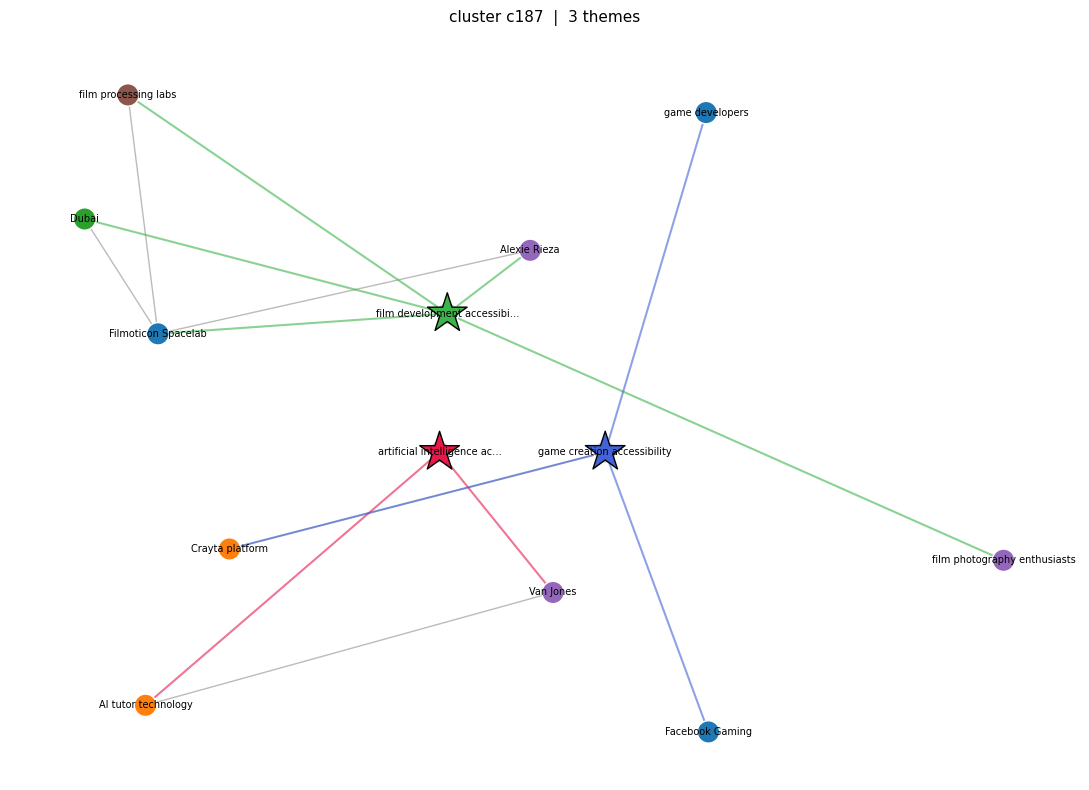

themes in this cluster:
  - artificial intelligence accessibility              2023-10-11 … 2023-10-11  (1 art.)
  - film development accessibility                     2021-05-29 … 2021-05-29  (1 art.)
  - game creation accessibility                        2021-06-05 … 2021-06-05  (1 art.)


In [18]:
show_cluster("c187")

### Interpretability

In [ ]:
best_alpha = float(best["alpha"])
best_entity_vecs = (
    winning_entity_vecs
    if winning_entity_vecs is not None
    else entity_vecs_for(bool(best["prop"]))
)

gold_cluster_of = dict(zip(gold["theme"], gold["gold_cluster_id"]))

In [ ]:
# Interpretability: why was a pair merged or split? (exact attribution)


def explain_pair(theme_a, theme_b, topk=8):
    ia, ib = theme_index[theme_a], theme_index[theme_b]
    phrase_cos = float(phrase_vecs[ia] @ phrase_vecs[ib])
    row_a, row_b = best_entity_vecs.getrow(ia), best_entity_vecs.getrow(ib)
    shared_products = row_a.multiply(row_b).tocoo()  # per-entity W[a,e]·W[b,e]
    entity_cos = float(shared_products.data.sum()) if shared_products.nnz else 0.0
    blend = best_alpha * phrase_cos + (1.0 - best_alpha) * entity_cos

    same_pred = final_clusters.get(theme_a) == final_clusters.get(theme_b)
    verdict = ""
    if theme_a in gold_cluster_of and theme_b in gold_cluster_of:
        same_gold = gold_cluster_of[theme_a] == gold_cluster_of[theme_b]
        ok = same_pred == same_gold
        verdict = (
            f"  |  gold: {'SAME' if same_gold else 'DIFFERENT'} story -> "
            f"{'correct' if ok else 'ERROR'}"
        )

    print(f"{theme_a!r}\n  vs  {theme_b!r}")
    print(
        f"predicted: {'MERGED (same cluster)' if same_pred else 'SPLIT (diff clusters)'}{verdict}"
    )
    print(
        f"score s = {blend:.3f}  =  α·phrase {best_alpha * phrase_cos:.3f}  +  (1-α)·entity {(1 - best_alpha) * entity_cos:.3f}"
        f"   (phrase cos {phrase_cos:.3f}, entity cos {entity_cos:.3f}, α={best_alpha})\n"
    )

    # exact additive contributions: one phrase row + one row per shared entity
    contributions = [("· phrase (semantic)", "—", best_alpha * phrase_cos)]
    for j, product in zip(shared_products.col, shared_products.data):
        entity = entity_list[j]
        contributions.append(
            (entity, entity_type.get(entity, "?"), (1 - best_alpha) * float(product))
        )
    contributions.sort(key=lambda c: -c[2])

    denom = blend if abs(blend) > 1e-12 else 1.0
    print(f"{'contribution to s':>18} {'%':>6} source")
    for name, kind, value in contributions[:topk]:
        tag = name if kind == "—" else f"{name} ({kind})"
        print(f"{value:>18.4f}   {value / denom:>6.1%}   {tag}")
    if len(contributions) > topk:
        rest = sum(value for _, _, value in contributions[topk:])
        print(
            f"{rest:>18.4f}   {rest / denom:>6.1%}   … {len(contributions) - topk} more entities"
        )

    # per-entity context: entities only one side carries score exactly 0 — they are
    # what the pair is *not* agreeing on, and they never enter s
    shared_entities = set(shared_products.col)
    print("\n entities carrying no shared weight (contribution 0):")
    for theme, row in ((theme_a, row_a), (theme_b, row_b)):
        row = row.tocoo()
        exclusive = sorted(
            (
                (entity_list[j], entity_type.get(entity_list[j], "?"), weight)
                for j, weight in zip(row.col, row.data)
                if j not in shared_entities
            ),
            key=lambda c: -c[2],
        )
        print(f"only in {theme!r}:")
        for name, kind, _ in exclusive[:topk] or [("(none)", "—", 0.0)]:
            tag = name if kind == "—" else f"{name} ({kind})"
            print(f"{0.0:>18.4f}   {0.0:>6.1%}   {tag}")

    # faithfulness: the parts must sum to the whole (exact, not approximate)
    assert (
        abs(sum(value for _, _, value in contributions) - blend) < 1e-9
    ), "attribution not faithful!"
    print(
        f"\n contributions sum to s = {blend:.3f} exactly (faithful, no surrogate model)"
    )


DEMO_PAIR = ("market impact of pandemic", "pandemic impact on investments")
demo_pair = DEMO_PAIR if all(t in theme_index for t in DEMO_PAIR) else None

if demo_pair is None:  # fall back to any gold same-story pair
    for _, group in gold.groupby("gold_cluster_id"):
        group_members = [t for t in group["theme"] if t in theme_index]
        if len(group_members) >= 2:
            demo_pair = (group_members[0], group_members[1])
            break

if demo_pair:
    explain_pair(*demo_pair)

'market impact of pandemic'
  vs  'pandemic impact on investments'
predicted: SPLIT (diff clusters)
score s = 0.654  =  α·phrase 0.548  +  (1-α)·entity 0.107   (phrase cos 0.782, entity cos 0.356, α=0.7)

 contribution to s      % source
            0.5477    83.7%   · phrase (semantic)
            0.1067    16.3%   COVID-19 (EVENT)

 entities carrying no shared weight (contribution 0):
only in 'market impact of pandemic':
            0.0000     0.0%   Electronic Shelf Label market (SECTOR)
            0.0000     0.0%   market growth (ECON_INDICATOR)
            0.0000     0.0%   global economy (ECON_INDICATOR)
only in 'pandemic impact on investments':
            0.0000     0.0%   hedge funds (ORG)
            0.0000     0.0%   hedge fund industry (SECTOR)

 contributions sum to s = 0.654 exactly (faithful, no surrogate model)


In [21]:
# Interpretability: what defines a canonical cluster?

members_by_cluster = {}
for theme, cluster in final_clusters.items():
    members_by_cluster.setdefault(cluster, []).append(theme)


def cluster_of(theme):
    return final_clusters.get(theme)


def explain_cluster(cluster_id, topk=10):
    members = members_by_cluster.get(cluster_id, [])
    if not members:
        print(f"no cluster {cluster_id!r}")
        return
    member_idx = [theme_index[t] for t in members if t in theme_index]
    member_vecs = best_entity_vecs[member_idx]  # unit-norm entity rows

    # signature = summed entity weight across members (the shared identity)
    mass = np.asarray(member_vecs.sum(axis=0)).ravel()
    support = np.asarray((member_vecs > 0).sum(axis=0)).ravel()  # members per entity
    order = np.argsort(-mass)

    # medoid = member most central to the entity signature -> auto label
    centroid = np.asarray(member_vecs.mean(axis=0)).ravel()
    sims = np.asarray(member_vecs @ centroid).ravel()
    medoid = members[int(np.argmax(sims))] if sims.size else members[0]

    print(f"cluster {cluster_id!r}  —  {len(members)} themes")
    print(f"medoid (auto-label): {medoid!r}\n")
    print("members:")
    for t in members[:15]:
        print(f"  - {t}{'   ← medoid' if t == medoid else ''}")
    if len(members) > 15:
        print(f"  … {len(members) - 15} more")
    print("\ndefining entities  (weight mass · member support):")
    shown = 0
    for j in order:
        if mass[j] <= 0 or shown >= topk:
            break
        entity = entity_list[j]
        print(
            f"{mass[j]:6.3f} {support[j]}/{len(members)} members {entity} ({entity_type.get(entity, '?')})"
        )
        shown += 1


# demo: the largest multi-theme cluster
largest_cluster = max(members_by_cluster.items(), key=lambda kv: len(kv[1]))[0]
explain_cluster(largest_cluster)

cluster 'c254'  —  53 themes
medoid (auto-label): 'pandemic caused disruption'

members:
  - Pandemic disruption
  - Pandemic-induced supply chain disruption
  - coronavirus pandemic disruption
  - covid supply disruption
  - covid19 pandemic disruption
  - economic disruption from pandemic
  - factory shutdowns from pandemic
  - global pandemic disruption
  - global pandemic driven disruption
  - health crisis supply disruption
  - manufacturing pandemic disruption
  - pandemic air travel disruption
  - pandemic aviation disruption
  - pandemic business disruption
  - pandemic business interruption
  … 38 more

defining entities  (weight mass · member support):
 3.364 7/53 members Covid-19 (EVENT)
 3.193 10/53 members Covid19 pandemic (EVENT)
 2.588 8/53 members Covid-19 pandemic (EVENT)
 2.117 3/53 members vacuum truck market (SECTOR)
 1.919 10/53 members COVID-19 pandemic (EVENT)
 1.855 3/53 members global automotive industry (SECTOR)
 1.673 2/53 members strict lockdown measures (EV